In [1]:
print("Hello World!")

Hello World!


In [2]:
from datasets import load_dataset
import pandas as pd
from IPython.display import display
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


ROOT = pathlib.Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
for p in [DATA_RAW, DATA_PROCESSED, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

ds = load_dataset("BadrAbu/CTR_Prediction")
split = "validation" if "validation" in ds else "train"
print(f"Using split: {split}")

sample = ds[split].shuffle(seed=42).select(range(100_000))
df = sample.to_pandas()
df.to_csv(DATA_PROCESSED / "BadrAbu_sample_100k.csv", index=False)

print(" Sample saved to:", DATA_PROCESSED / "BadrAbu_sample_100k.csv")


d:\projects\Ai\ML_project-CTR_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using split: train
 Sample saved to: d:\projects\Ai\ML_project-CTR_Prediction\notebooks\data\processed\BadrAbu_sample_100k.csv


In [60]:
import polars as pl


In [19]:
FIGURES = pathlib.Path.cwd() / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

In [41]:
# === Helper functions for plots ===
import matplotlib.pyplot as plt

def click_rate(df, by):
    """Group by column(s) and calculate click-through rate (CTR)."""
    g = df.groupby(by, dropna=False)["click"].agg(["count", "mean"]).reset_index()
    g.rename(columns={"mean": "ctr"}, inplace=True)
    return g

def savefig(path):
    """Save the current Matplotlib figure neatly."""
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()


In [5]:
print("\n=== Info ===")
print(df.info())



=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                100000 non-null  uint64
 1   click             100000 non-null  int64 
 2   hour              100000 non-null  int64 
 3   C1                100000 non-null  int64 
 4   banner_pos        100000 non-null  int64 
 5   site_id           100000 non-null  object
 6   site_domain       100000 non-null  object
 7   site_category     100000 non-null  object
 8   app_id            100000 non-null  object
 9   app_domain        100000 non-null  object
 10  app_category      100000 non-null  object
 11  device_id         100000 non-null  object
 12  device_ip         100000 non-null  object
 13  device_model      100000 non-null  object
 14  device_type       100000 non-null  int64 
 15  device_conn_type  100000 non-null  int64 
 16  C14               100000 

In [33]:
print("Shape:", df.shape)
print("=== dtypes ===")
print(df.dtypes)

print("=== label distribution ===")
print(df["click"].value_counts(normalize=True))

Shape: (100000, 24)
=== dtypes ===
id                  uint64
click                int64
hour                 int64
C1                   int64
banner_pos           int64
site_id             object
site_domain         object
site_category       object
app_id              object
app_domain          object
app_category        object
device_id           object
device_ip           object
device_model        object
device_type          int64
device_conn_type     int64
C14                  int64
C15                  int64
C16                  int64
C17                  int64
C18                  int64
C19                  int64
C20                  int64
C21                  int64
dtype: object
=== label distribution ===
click
0   1
1   0
Name: proportion, dtype: float64


In [4]:
pd.set_option('display.float_format', '{:.0f}'.format)
display(df.describe())

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
mean,9214847570174173184,0,14102559,1005,0,1,0,18877,319,60,2117,1,226,53104,83
std,5317054296004869120,0,297,1,1,1,1,4918,22,48,605,1,348,49964,70
min,21914157702358,0,14102100,1001,0,0,0,375,120,20,112,0,33,-1,1
25%,4618437780367589376,0,14102304,1005,0,1,0,16920,320,50,1863,0,35,-1,23
50%,9223765649693407232,0,14102602,1005,0,1,0,20352,320,50,2323,2,39,100039,61
75%,13807220720142798848,0,14102814,1005,1,1,0,21916,320,50,2526,3,171,100086,101
max,18446377089592328192,1,14103023,1012,7,5,5,24044,1024,1024,2757,3,1839,100248,255


In [45]:

print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])



=== Missing Values ===
Series([], dtype: int64)


In [36]:
print("\n=== Label Distribution ===")
print(df["click"].value_counts(normalize=True))



=== Label Distribution ===
click
0   1
1   0
Name: proportion, dtype: float64


C:\Users\A-plus\AppData\Local\Temp\ipykernel_4756\4036758477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="click", data=df, palette="viridis")


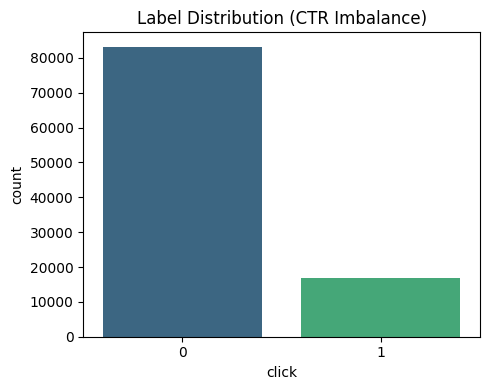

In [37]:
plt.figure(figsize=(5, 4))
sns.countplot(x="click", data=df, palette="viridis")
plt.title("Label Distribution (CTR Imbalance)")
plt.xlabel("click")
plt.ylabel("count")
plt.tight_layout()

plt.savefig(FIGURES / "label_distribution.png", dpi=300)
plt.show()

In [38]:
label_dist = df["click"].value_counts(normalize=True)
neg, pos = label_dist.get(0, 0) * 100, label_dist.get(1, 0) * 100

print(f"\n📉 Dataset Imbalance: Class 0 = {neg:.2f}%, Class 1 = {pos:.2f}%")

print("\n✅ EDA complete! Figures saved in:", FIGURES)




📉 Dataset Imbalance: Class 0 = 83.18%, Class 1 = 16.82%

✅ EDA complete! Figures saved in: d:\projects\Ai\ML_project-CTR_Prediction\notebooks\reports\figures


In [56]:
# %% 4) CTR by hour of day (line)
if "hour_of_day" in df.columns:
    h = click_rate(df, "hour_of_day").sort_values("hour_of_day")
    plt.figure(figsize=(6,4))
    sns.lineplot(x="hour_of_day", y="ctr", data=h, marker="o")
    plt.title("CTR by Hour of Day")
    plt.xlabel("hour_of_day"); plt.ylabel("CTR")
    savefig(FIGURES / "04_ctr_by_hour.png")


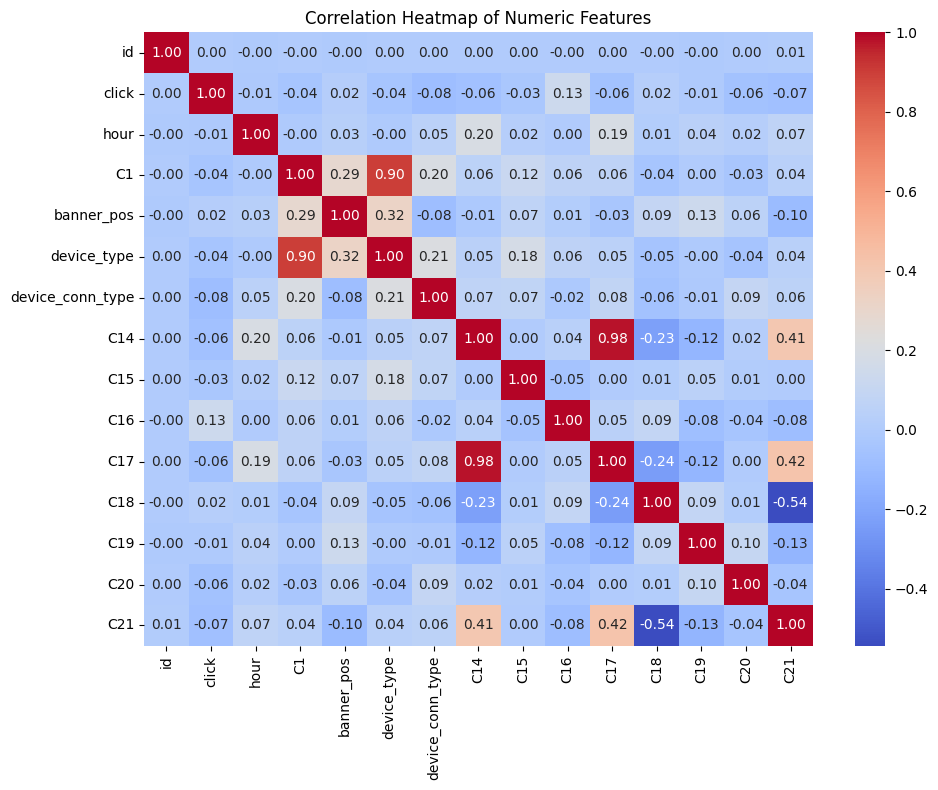

In [47]:
# %% Normal correlation heatmap (for numeric features)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(FIGURES / "correlation_heatmap_coolwarm.png", dpi=300)
plt.show()


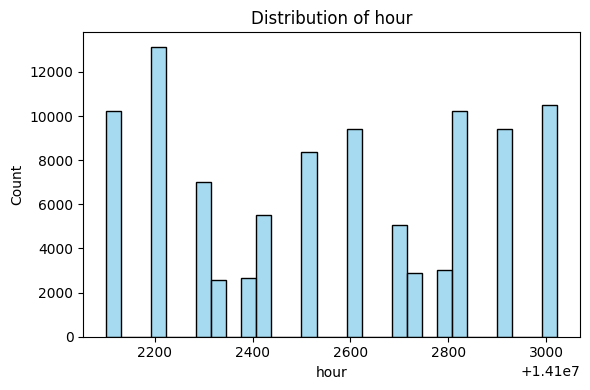

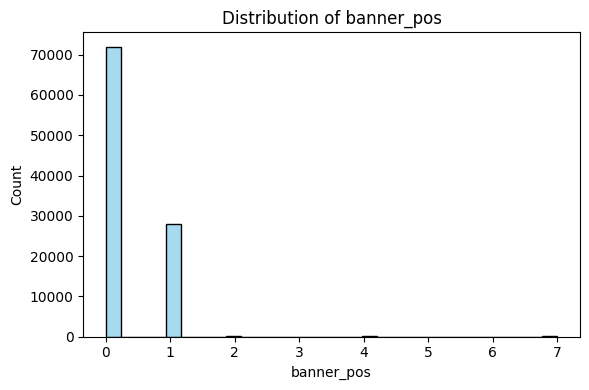

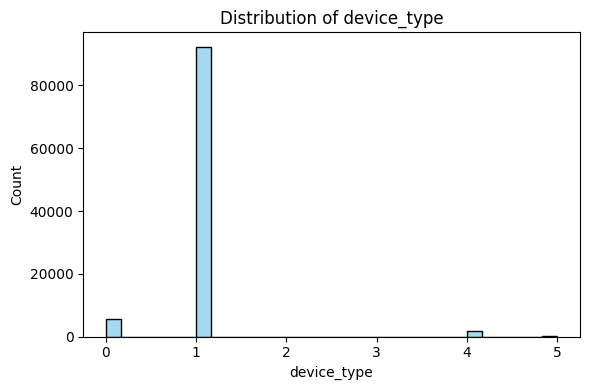

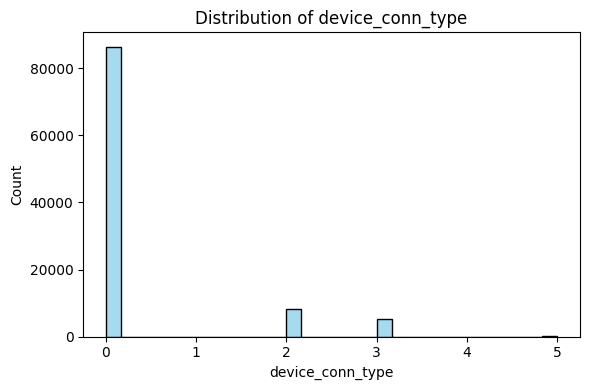

In [49]:
# %% Distributions of main categorical/numeric features
cols_to_plot = ["hour", "banner_pos", "device_type", "device_conn_type"]
for col in cols_to_plot:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=False, bins=30, color="skyblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(FIGURES / f"dist_{col}.png", dpi=300)
        plt.show()


C:\Users\A-plus\AppData\Local\Temp\ipykernel_4756\3252585581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="ctr", data=ctr_df, palette="viridis")


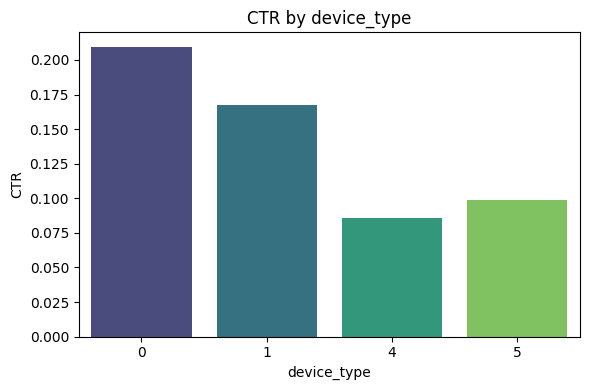

C:\Users\A-plus\AppData\Local\Temp\ipykernel_4756\3252585581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="ctr", data=ctr_df, palette="viridis")


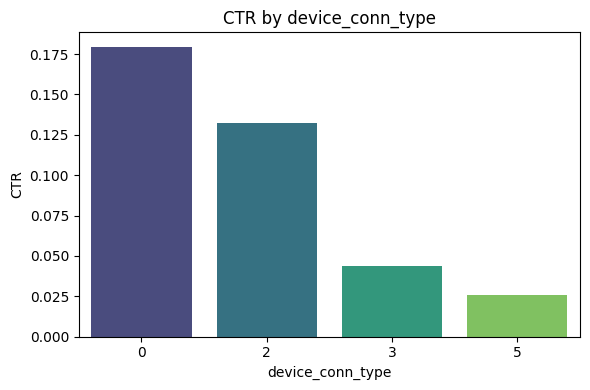

C:\Users\A-plus\AppData\Local\Temp\ipykernel_4756\3252585581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="ctr", data=ctr_df, palette="viridis")


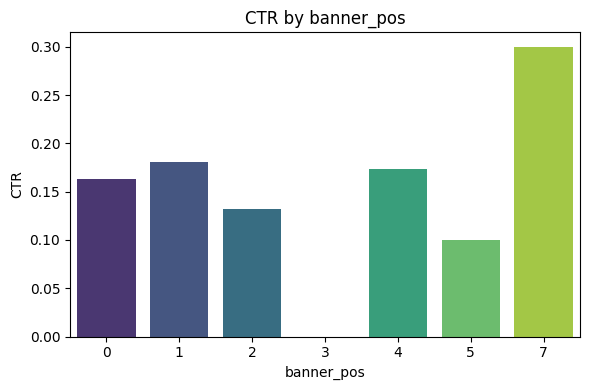

In [50]:
# %% CTR comparison for categorical features
for col in ["device_type", "device_conn_type", "banner_pos"]:
    if col in df.columns:
        ctr_df = click_rate(df, col).sort_values("ctr", ascending=False)
        plt.figure(figsize=(6,4))
        sns.barplot(x=col, y="ctr", data=ctr_df, palette="viridis")
        plt.title(f"CTR by {col}")
        plt.xlabel(col); plt.ylabel("CTR")
        plt.tight_layout()
        plt.savefig(FIGURES / f"ctr_by_{col}.png", dpi=300)
        plt.show()


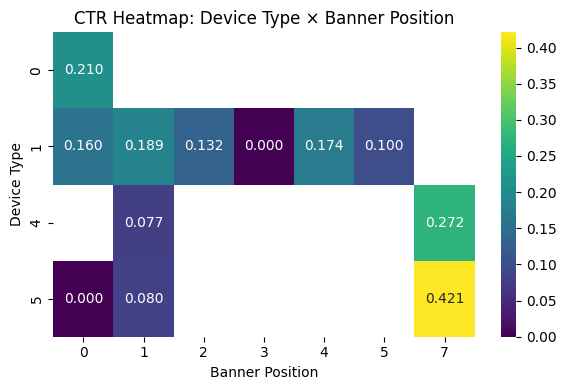

In [51]:
# %% CTR heatmap: device_type × banner_pos
if {"device_type","banner_pos"}.issubset(df.columns):
    hmap = click_rate(df, ["device_type","banner_pos"])
    pivot = hmap.pivot(index="device_type", columns="banner_pos", values="ctr")
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")
    plt.title("CTR Heatmap: Device Type × Banner Position")
    plt.xlabel("Banner Position"); plt.ylabel("Device Type")
    plt.tight_layout()
    plt.savefig(FIGURES / "ctr_heatmap_device_banner.png", dpi=300)
    plt.show()
